# Bước 4: Data Analysis with Python
## UK Weather & Health: Weekly Deaths and Temperature (2016–2024)
---

## 4.1 Import Libraries & Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import warnings

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)
sns.set_theme(style='whitegrid')

# Load dataset đã xử lý từ Notebook 2
df = pd.read_csv('uk_weather_health_weekly_CLEANED.csv',
                  parse_dates=['week_start_sat', 'week_start_mon', 'week_end'])

print(f'Dataset: {df.shape[0]} rows × {df.shape[1]} columns')
print(f'Các cột: {list(df.columns)}')
df.head()

Dataset: 442 rows × 15 columns
Các cột: ['week_start_sat', 'week_start_mon', 'week_end', 'deaths_total', 'tasmax_mean_weekly_degC', 'tasmax_max_weekly_degC', 'year', 'month', 'week_of_year', 'quarter', 'season', 'temp_range_weekly', 'IsSurge', 'tasmax_mean_scaled', 'tasmax_max_scaled']


,week_start_sat,week_start_mon,week_end,deaths_total,tasmax_mean_weekly_degC,tasmax_max_weekly_degC,year,month,week_of_year,quarter,season,temp_range_weekly,IsSurge,tasmax_mean_scaled,tasmax_max_scaled
0,2016-01-02,2016-01-04,2016-01-08,13045.00,7.36,8.84,2016,1,1,1,Winter,1.48,1,-1.14,-1.23
1,2016-01-09,2016-01-11,2016-01-15,11501.00,5.13,7.14,2016,1,2,1,Winter,2.00,0,-1.57,-1.54
2,2016-01-16,2016-01-18,2016-01-22,11473.00,5.36,10.23,2016,1,3,1,Winter,4.87,0,-1.52,-0.97
3,2016-01-23,2016-01-25,2016-01-29,11317.00,11.17,13.15,2016,1,4,1,Winter,1.99,0,-0.41,-0.44
4,2016-01-30,2016-02-01,2016-02-05,11052.00,8.78,11.27,2016,2,5,1,Winter,2.49,0,-0.87,-0.78


## 4.2 Ma trận tương quan giữa `deaths_total` và `tasmax_mean`

Sử dụng **Pearson** (tuyến tính) và **Spearman** (đơn điệu) để đánh giá mối quan hệ.

In [2]:
# Các biến số cần tính tương quan
corr_cols = ['deaths_total', 'tasmax_mean_weekly_degC', 'tasmax_max_weekly_degC', 'temp_range_weekly']

# Pearson Correlation
pearson_corr = df[corr_cols].corr(method='pearson')
print('MA TRẬN TƯƠNG QUAN PEARSON')
print('=' * 60)
print(pearson_corr.round(3))

# Spearman Correlation
spearman_corr = df[corr_cols].corr(method='spearman')
print('\nMA TRẬN TƯƠNG QUAN SPEARMAN')
print('=' * 60)
print(spearman_corr.round(3))

MA TRẬN TƯƠNG QUAN PEARSON
                         deaths_total  tasmax_mean_weekly_degC  \
deaths_total                     1.00                    -0.47   
tasmax_mean_weekly_degC         -0.47                     1.00   
tasmax_max_weekly_degC          -0.45                     0.97   
temp_range_weekly                0.04                     0.07   

                         tasmax_max_weekly_degC  temp_range_weekly  
deaths_total                              -0.45               0.04  
tasmax_mean_weekly_degC                    0.97               0.07  
tasmax_max_weekly_degC                     1.00               0.29  
temp_range_weekly                          0.29               1.00  

MA TRẬN TƯƠNG QUAN SPEARMAN
                         deaths_total  tasmax_mean_weekly_degC  \
deaths_total                     1.00                    -0.61   
tasmax_mean_weekly_degC         -0.61                     1.00   
tasmax_max_weekly_degC          -0.59                     0.98   
temp

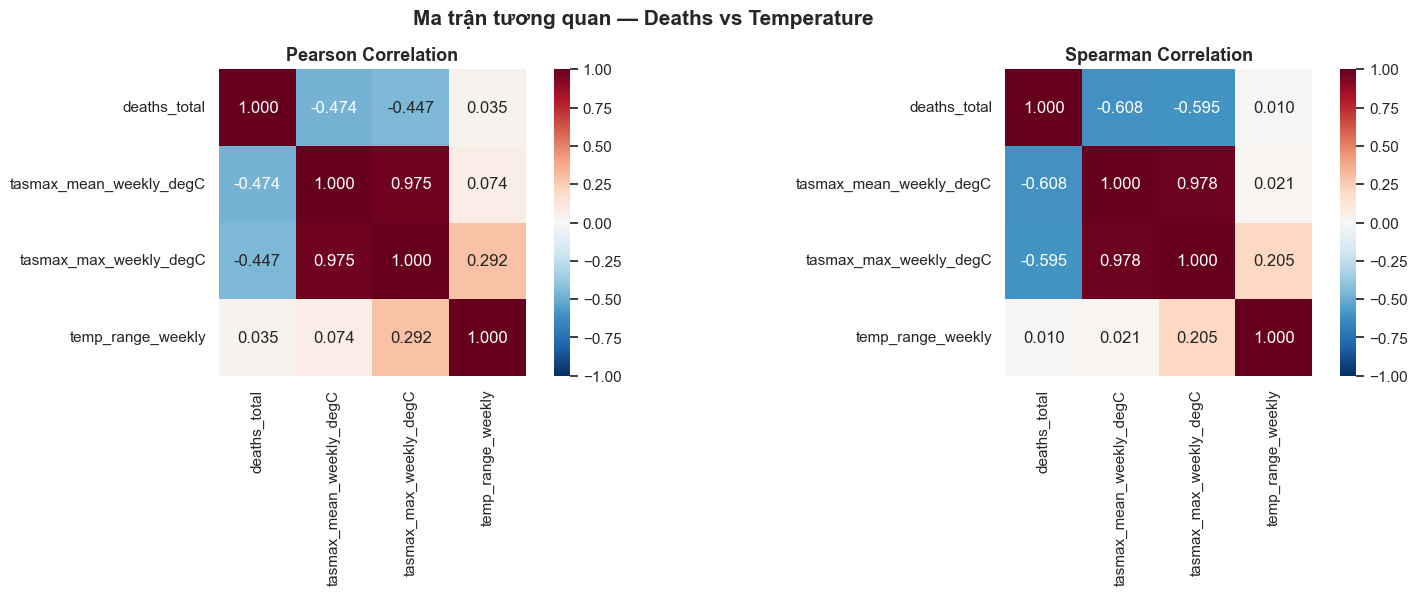

deaths_total vs tasmax_mean:
  Pearson:  r = -0.4740, p-value = 3.82e-26
  Spearman: r = -0.6079, p-value = 5.13e-46


In [3]:
# Heatmap tương quan
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(pearson_corr, annot=True, fmt='.3f', cmap='RdBu_r', center=0,
            vmin=-1, vmax=1, square=True, ax=axes[0])
axes[0].set_title('Pearson Correlation', fontweight='bold', fontsize=13)

sns.heatmap(spearman_corr, annot=True, fmt='.3f', cmap='RdBu_r', center=0,
            vmin=-1, vmax=1, square=True, ax=axes[1])
axes[1].set_title('Spearman Correlation', fontweight='bold', fontsize=13)

plt.suptitle('Ma trận tương quan — Deaths vs Temperature', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

# Kiểm định p-value cho tương quan chính
r_pearson, p_pearson = stats.pearsonr(df['deaths_total'], df['tasmax_mean_weekly_degC'])
r_spearman, p_spearman = stats.spearmanr(df['deaths_total'], df['tasmax_mean_weekly_degC'])
print(f'deaths_total vs tasmax_mean:')
print(f'  Pearson:  r = {r_pearson:.4f}, p-value = {p_pearson:.2e}')
print(f'  Spearman: r = {r_spearman:.4f}, p-value = {p_spearman:.2e}')

## 4.3 Ảnh hưởng của tháng (Month) đến số ca tử vong trung bình

In [4]:
# Trung bình tử vong theo tháng
monthly_deaths = df.groupby('month').agg(
    avg_deaths=('deaths_total', 'mean'),
    std_deaths=('deaths_total', 'std'),
    avg_temp=('tasmax_mean_weekly_degC', 'mean'),
    count=('deaths_total', 'count')
).round(1)

print('TRUNG BÌNH TỬ VONG THEO THÁNG')
print('=' * 60)
print(monthly_deaths)

# ANOVA — tháng có ảnh hưởng có ý nghĩa thống kê?
groups = [group['deaths_total'].values for _, group in df.groupby('month')]
f_stat, p_value = stats.f_oneway(*groups)
print(f'\nANOVA Test: F = {f_stat:.2f}, p-value = {p_value:.2e}')
if p_value < 0.05:
    print('→ Có sự khác biệt có ý nghĩa thống kê giữa các tháng (p < 0.05)')
else:
    print('→ Không có sự khác biệt có ý nghĩa (p >= 0.05)')

TRUNG BÌNH TỬ VONG THEO THÁNG
       avg_deaths  std_deaths  avg_temp  count
month                                         
1        13636.60     2045.40      7.10     38
2        11886.00     1273.10      7.80     37
3        11004.60     1284.90      9.80     38
4        11793.10     3281.80     12.20     35
5        10015.90     1598.60     16.30     34
6         9900.40      721.10     18.70     37
7         9602.80      624.10     20.30     37
8         9345.80      868.70     19.70     37
9         9833.50      608.40     17.30     38
10       10401.30      678.90     13.60     41
11       11134.60      690.50      9.30     32
12       10948.40     1820.90      7.90     38

ANOVA Test: F = 25.15, p-value = 3.94e-40
→ Có sự khác biệt có ý nghĩa thống kê giữa các tháng (p < 0.05)


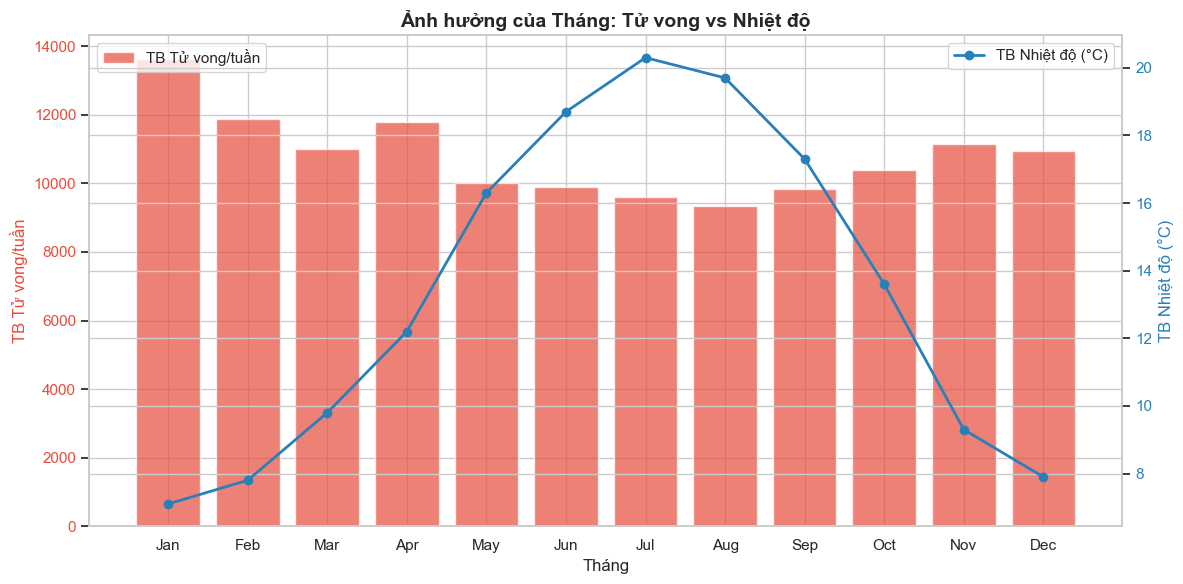

In [5]:
# Biểu đồ bar: TB tử vong theo tháng + line nhiệt độ
fig, ax1 = plt.subplots(figsize=(12, 6))

months = monthly_deaths.index
month_labels = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
                'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

bars = ax1.bar(months, monthly_deaths['avg_deaths'], color='#e74c3c', alpha=0.7,
               label='TB Tử vong/tuần', edgecolor='white')
ax1.set_xlabel('Tháng', fontsize=12)
ax1.set_ylabel('TB Tử vong/tuần', color='#e74c3c', fontsize=12)
ax1.set_xticks(months)
ax1.set_xticklabels(month_labels)
ax1.tick_params(axis='y', labelcolor='#e74c3c')

ax2 = ax1.twinx()
ax2.plot(months, monthly_deaths['avg_temp'], color='#2980b9', marker='o',
         linewidth=2, label='TB Nhiệt độ (°C)')
ax2.set_ylabel('TB Nhiệt độ (°C)', color='#2980b9', fontsize=12)
ax2.tick_params(axis='y', labelcolor='#2980b9')

ax1.legend(loc='upper left')
ax2.legend(loc='upper right')
plt.title('Ảnh hưởng của Tháng: Tử vong vs Nhiệt độ', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.show()

## 4.4 Biểu đồ đường — Biến động Nhiệt độ & Tử vong theo thời gian

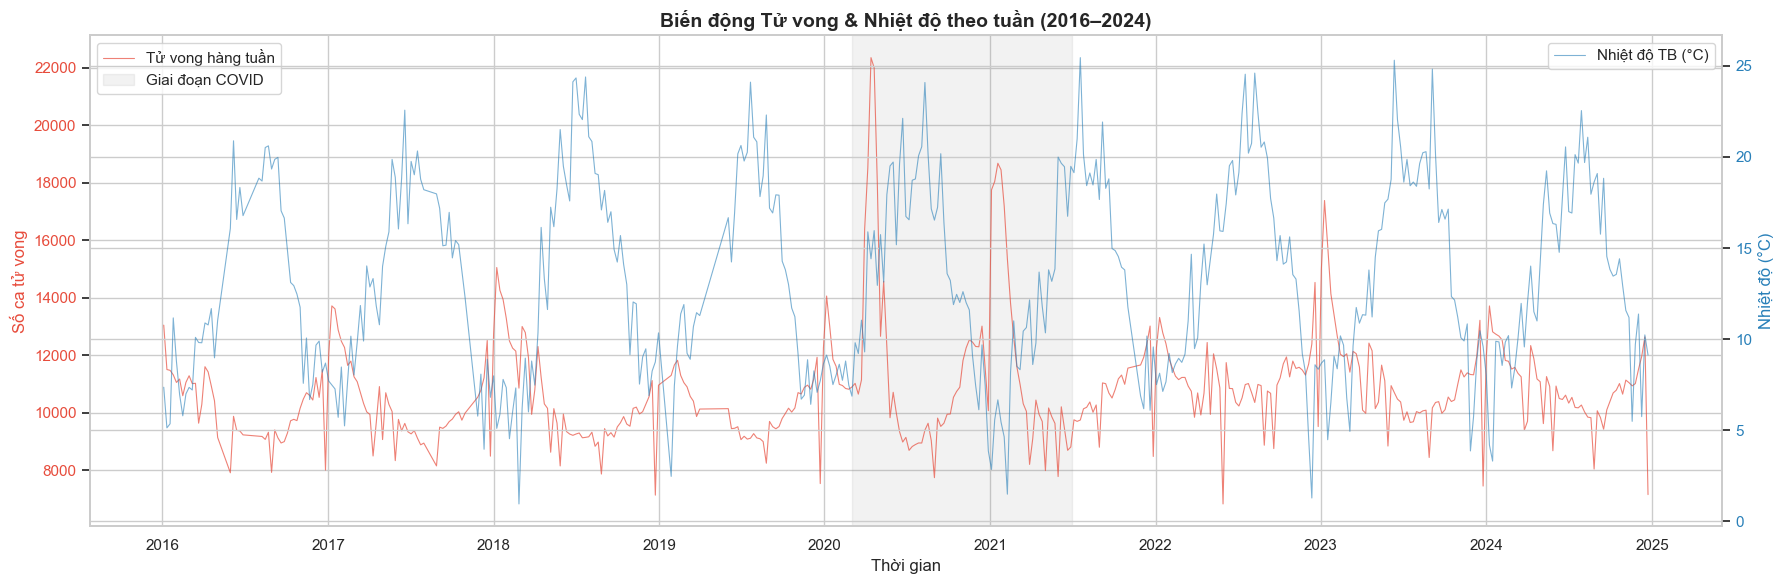

In [6]:
fig, ax1 = plt.subplots(figsize=(18, 6))

# Line: Tử vong
ax1.plot(df['week_start_mon'], df['deaths_total'], color='#e74c3c', alpha=0.7,
         linewidth=0.8, label='Tử vong hàng tuần')
ax1.set_xlabel('Thời gian', fontsize=12)
ax1.set_ylabel('Số ca tử vong', color='#e74c3c', fontsize=12)
ax1.tick_params(axis='y', labelcolor='#e74c3c')

# Line: Nhiệt độ
ax2 = ax1.twinx()
ax2.plot(df['week_start_mon'], df['tasmax_mean_weekly_degC'], color='#2980b9',
         alpha=0.6, linewidth=0.8, label='Nhiệt độ TB (°C)')
ax2.set_ylabel('Nhiệt độ (°C)', color='#2980b9', fontsize=12)
ax2.tick_params(axis='y', labelcolor='#2980b9')

# COVID highlight
ax1.axvspan(pd.Timestamp('2020-03-01'), pd.Timestamp('2021-06-30'),
            alpha=0.1, color='gray', label='Giai đoạn COVID')

ax1.legend(loc='upper left')
ax2.legend(loc='upper right')
plt.title('Biến động Tử vong & Nhiệt độ theo tuần (2016–2024)', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.show()

## 4.5 Phân tích Nắng nóng — So sánh tuần `tasmax > 25°C` vs tuần bình thường

In [7]:
# Phân nhóm
df['heatwave'] = (df['tasmax_mean_weekly_degC'] > 25).astype(int)

heat_compare = df.groupby('heatwave').agg(
    count=('deaths_total', 'count'),
    avg_deaths=('deaths_total', 'mean'),
    std_deaths=('deaths_total', 'std'),
    min_deaths=('deaths_total', 'min'),
    max_deaths=('deaths_total', 'max'),
    avg_temp=('tasmax_mean_weekly_degC', 'mean')
).round(1)
heat_compare.index = ['Bình thường (≤25°C)', 'Nắng nóng (>25°C)']

print('SO SÁNH TỬ VONG: NẮNG NÓNG vs BÌNH THƯỜNG')
print('=' * 65)
print(heat_compare)

# T-test
normal_deaths = df[df['heatwave'] == 0]['deaths_total']
hot_deaths = df[df['heatwave'] == 1]['deaths_total']

if len(hot_deaths) >= 2:
    t_stat, p_val = stats.ttest_ind(normal_deaths, hot_deaths, equal_var=False)
    cohens_d = (normal_deaths.mean() - hot_deaths.mean()) / np.sqrt(
        (normal_deaths.std()**2 + hot_deaths.std()**2) / 2)
    print(f'\nWelch t-test: t = {t_stat:.3f}, p = {p_val:.4f}')
    print(f"Cohen's d = {cohens_d:.3f}")
    if p_val < 0.05:
        print('→ Sự khác biệt CÓ ý nghĩa thống kê')
    else:
        print('→ Sự khác biệt KHÔNG có ý nghĩa thống kê')
else:
    print(f'\n Chỉ có {len(hot_deaths)} tuần nắng nóng — không đủ mẫu cho t-test.')

SO SÁNH TỬ VONG: NẮNG NÓNG vs BÌNH THƯỜNG
                     count  avg_deaths  std_deaths  min_deaths  max_deaths  \
Bình thường (≤25°C)    440    10792.90     1889.40     6825.00    22351.00   
Nắng nóng (>25°C)        2    10222.00      676.00     9744.00    10700.00   

                     avg_temp  
Bình thường (≤25°C)     13.30  
Nắng nóng (>25°C)       25.40  

Welch t-test: t = 1.174, p = 0.4389
Cohen's d = 0.402
→ Sự khác biệt KHÔNG có ý nghĩa thống kê


## 4.6 Boxplot số ca tử vong theo từng Quý

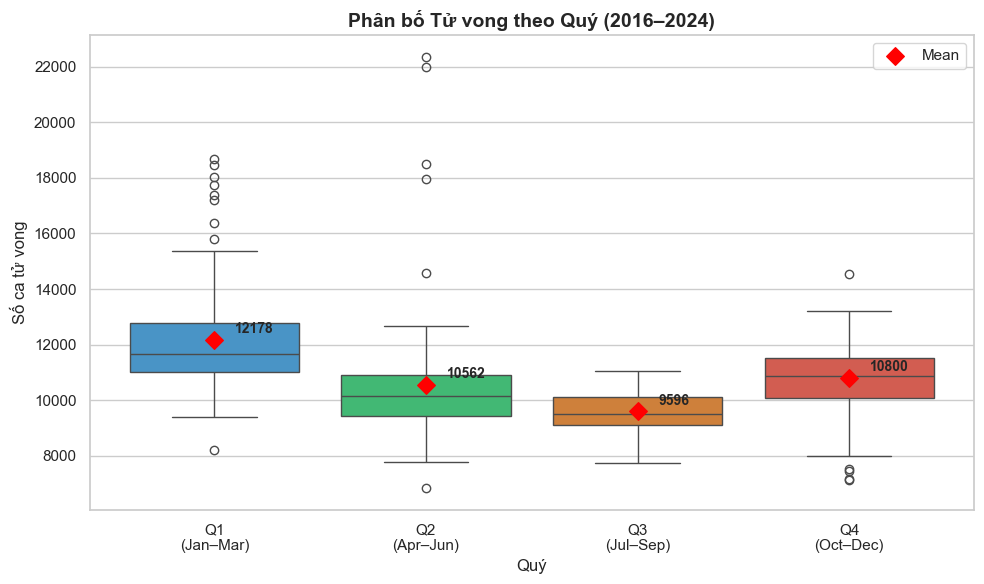


Thống kê theo Quý:
         count     mean     std     min      25%      50%      75%      max
quarter                                                                    
1       113.00 12178.00 1915.00 8201.00 11022.00 11660.00 12776.00 18676.00
2       106.00 10562.00 2286.00 6825.00  9448.00 10142.00 10922.00 22351.00
3       112.00  9596.00  731.00 7739.00  9113.00  9520.00 10106.00 11035.00
4       111.00 10800.00 1232.00 7131.00 10086.00 10882.00 11515.00 14530.00


In [8]:
fig, ax = plt.subplots(figsize=(10, 6))

quarter_labels = {1: 'Q1\n(Jan–Mar)', 2: 'Q2\n(Apr–Jun)',
                  3: 'Q3\n(Jul–Sep)', 4: 'Q4\n(Oct–Dec)'}
df['quarter_label'] = df['quarter'].map(quarter_labels)

palette = ['#3498db', '#2ecc71', '#e67e22', '#e74c3c']
sns.boxplot(x='quarter_label', y='deaths_total', data=df, palette=palette,
            order=['Q1\n(Jan–Mar)', 'Q2\n(Apr–Jun)', 'Q3\n(Jul–Sep)', 'Q4\n(Oct–Dec)'],
            ax=ax)

# Thêm trung bình
means = df.groupby('quarter_label')['deaths_total'].mean()
for i, q in enumerate(['Q1\n(Jan–Mar)', 'Q2\n(Apr–Jun)', 'Q3\n(Jul–Sep)', 'Q4\n(Oct–Dec)']):
    ax.scatter(i, means[q], color='red', zorder=5, s=80, marker='D', label='Mean' if i == 0 else '')
    ax.annotate(f'{means[q]:.0f}', (i, means[q]), textcoords='offset points',
                xytext=(15, 5), fontweight='bold', fontsize=10)

ax.set_xlabel('Quý', fontsize=12)
ax.set_ylabel('Số ca tử vong', fontsize=12)
ax.set_title('Phân bố Tử vong theo Quý (2016–2024)', fontweight='bold', fontsize=14)
ax.legend()
plt.tight_layout()
plt.show()

# Thống kê theo quý
print('\nThống kê theo Quý:')
print(df.groupby('quarter')['deaths_total'].describe().round(0))

## 4.7 Phân tích độ trễ (Lag Effect) — Nhiệt độ tuần này → Tử vong tuần sau

In [9]:
# Tạo biến lag
for lag in range(1, 5):
    df[f'temp_lag_{lag}'] = df['tasmax_mean_weekly_degC'].shift(lag)

# Tương quan giữa deaths và các lag nhiệt độ
lag_cols = ['tasmax_mean_weekly_degC'] + [f'temp_lag_{i}' for i in range(1, 5)]
lag_labels = ['Tuần hiện tại (lag 0)', 'Lag 1 tuần', 'Lag 2 tuần', 'Lag 3 tuần', 'Lag 4 tuần']

print('TƯƠNG QUAN: deaths_total vs Nhiệt độ (có lag)')
print('=' * 60)
lag_results = []
for col, label in zip(lag_cols, lag_labels):
    valid = df[['deaths_total', col]].dropna()
    r, p = stats.pearsonr(valid['deaths_total'], valid[col])
    lag_results.append({'Biến': label, 'Pearson r': round(r, 4), 'p-value': f'{p:.2e}', 'n': len(valid)})
    print(f'{label:25s}: r = {r:.4f}, p = {p:.2e}')

lag_df = pd.DataFrame(lag_results)
lag_df

TƯƠNG QUAN: deaths_total vs Nhiệt độ (có lag)
Tuần hiện tại (lag 0)    : r = -0.4740, p = 3.82e-26
Lag 1 tuần               : r = -0.4852, p = 2.01e-27
Lag 2 tuần               : r = -0.4917, p = 3.70e-28
Lag 3 tuần               : r = -0.4886, p = 1.02e-27
Lag 4 tuần               : r = -0.4577, p = 4.59e-24


,Biến,Pearson r,p-value,n
0,Tuần hiện tại (lag 0),-0.47,3.82e-26,442
1,Lag 1 tuần,-0.49,2.01e-27,441
2,Lag 2 tuần,-0.49,3.70e-28,440
3,Lag 3 tuần,-0.49,1.02e-27,439
4,Lag 4 tuần,-0.46,4.59e-24,438


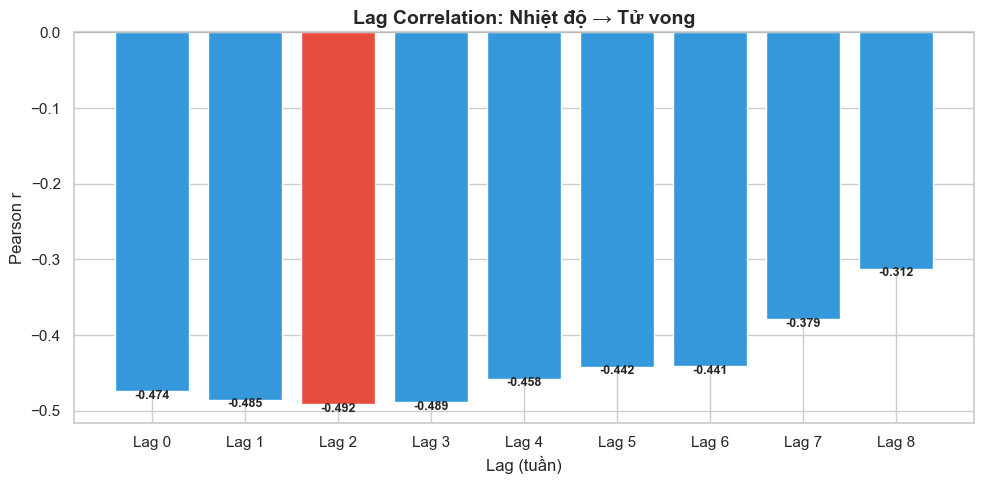


→ Lag mạnh nhất: Lag 2 (r = -0.4917)


In [10]:
# Biểu đồ tương quan theo lag
lag_corrs = [stats.pearsonr(df['deaths_total'].iloc[lag:], df['tasmax_mean_weekly_degC'].iloc[:len(df)-lag])[0]
             for lag in range(0, 9)]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(range(0, 9), lag_corrs, color=['#e74c3c' if abs(c) == max(abs(x) for x in lag_corrs) else '#3498db'
              for c in lag_corrs], edgecolor='white')
ax.set_xlabel('Lag (tuần)', fontsize=12)
ax.set_ylabel('Pearson r', fontsize=12)
ax.set_title('Lag Correlation: Nhiệt độ → Tử vong', fontweight='bold', fontsize=14)
ax.axhline(0, color='black', linewidth=0.5)
for i, v in enumerate(lag_corrs):
    ax.text(i, v + 0.01 * (-1 if v < 0 else 1), f'{v:.3f}', ha='center', fontsize=9, fontweight='bold')
ax.set_xticks(range(0, 9))
ax.set_xticklabels([f'Lag {i}' for i in range(0, 9)])
plt.tight_layout()
plt.show()

best_lag = np.argmax([abs(c) for c in lag_corrs])
print(f'\n→ Lag mạnh nhất: Lag {best_lag} (r = {lag_corrs[best_lag]:.4f})')

## 4.8 Thống kê mô tả (Mean, Median, Std) cho từng cột số

In [11]:
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()

desc_stats = pd.DataFrame({
    'Mean': df[num_cols].mean(),
    'Median': df[num_cols].median(),
    'Std': df[num_cols].std(),
    'Min': df[num_cols].min(),
    'Max': df[num_cols].max(),
    'Skewness': df[num_cols].skew(),
    'Kurtosis': df[num_cols].kurtosis()
}).round(3)

print('THỐNG KÊ MÔ TẢ — Tất cả biến số')
print('=' * 80)
desc_stats

THỐNG KÊ MÔ TẢ — Tất cả biến số


,Mean,Median,Std,Min,Max,Skewness,Kurtosis
deaths_total,10790.34,10536.00,1885.78,6825.00,22351.00,2.12,8.38
tasmax_mean_weekly_degC,13.33,13.04,5.24,0.96,25.45,0.10,-0.91
tasmax_max_weekly_degC,15.54,15.11,5.47,2.47,31.36,0.23,-0.68
year,2020.12,2020.00,2.58,2016.00,2024.00,-0.06,-1.23
month,6.50,7.00,3.47,1.00,12.00,-0.01,-1.22
week_of_year,26.58,27.00,15.16,1.00,53.00,-0.00,-1.22
quarter,2.50,3.00,1.12,1.00,4.00,-0.01,-1.38
temp_range_weekly,2.21,1.98,1.21,0.00,7.64,1.14,1.93
IsSurge,0.25,0.00,0.43,0.00,1.00,1.15,-0.68
tasmax_mean_scaled,0.00,-0.06,1.00,-2.36,2.31,0.10,-0.91


## 4.9 Rolling Mean (3 tuần) — Làm mịn dữ liệu tử vong

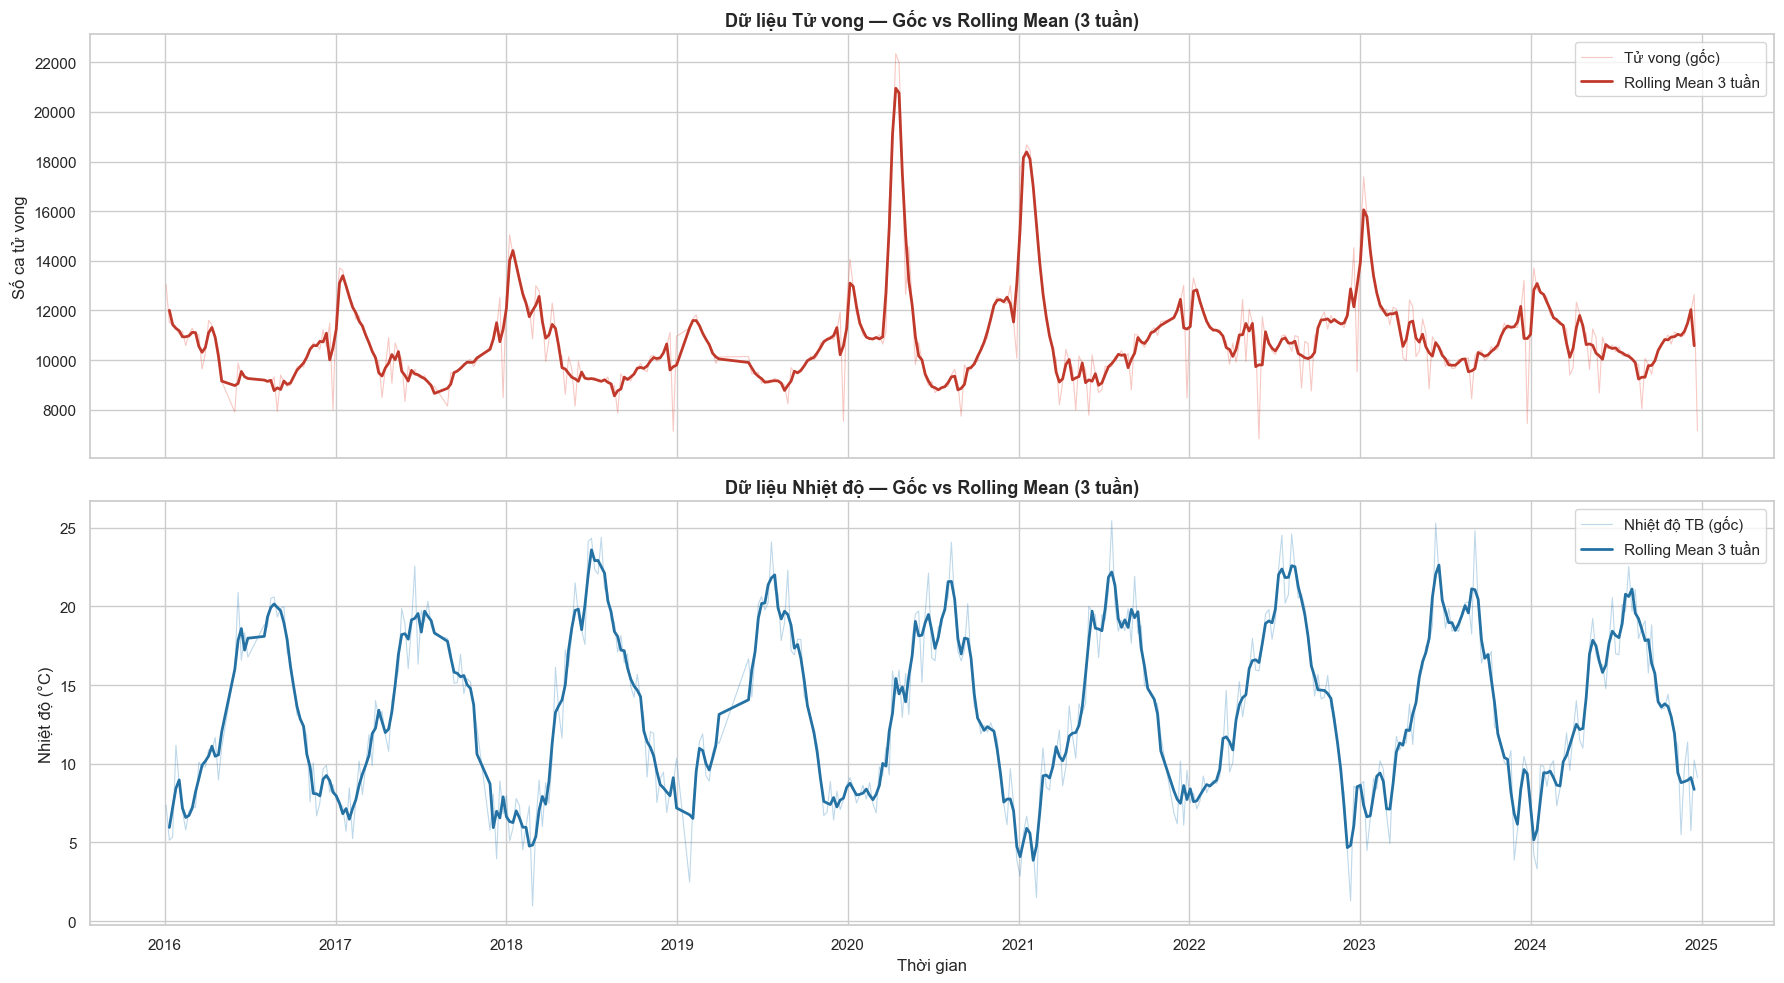

In [12]:
# Tính rolling mean 3 tuần
df['deaths_rolling_3w'] = df['deaths_total'].rolling(window=3, center=True).mean()
df['temp_rolling_3w'] = df['tasmax_mean_weekly_degC'].rolling(window=3, center=True).mean()

fig, axes = plt.subplots(2, 1, figsize=(18, 10), sharex=True)

# Chart 1: Tử vong gốc vs Rolling
axes[0].plot(df['week_start_mon'], df['deaths_total'], color='#e74c3c',
             alpha=0.3, linewidth=0.8, label='Tử vong (gốc)')
axes[0].plot(df['week_start_mon'], df['deaths_rolling_3w'], color='#c0392b',
             linewidth=2, label='Rolling Mean 3 tuần')
axes[0].set_ylabel('Số ca tử vong', fontsize=12)
axes[0].set_title('Dữ liệu Tử vong — Gốc vs Rolling Mean (3 tuần)', fontweight='bold', fontsize=13)
axes[0].legend(fontsize=11)

# Chart 2: Nhiệt độ gốc vs Rolling
axes[1].plot(df['week_start_mon'], df['tasmax_mean_weekly_degC'], color='#2980b9',
             alpha=0.3, linewidth=0.8, label='Nhiệt độ TB (gốc)')
axes[1].plot(df['week_start_mon'], df['temp_rolling_3w'], color='#2471a3',
             linewidth=2, label='Rolling Mean 3 tuần')
axes[1].set_xlabel('Thời gian', fontsize=12)
axes[1].set_ylabel('Nhiệt độ (°C)', fontsize=12)
axes[1].set_title('Dữ liệu Nhiệt độ — Gốc vs Rolling Mean (3 tuần)', fontweight='bold', fontsize=13)
axes[1].legend(fontsize=11)

plt.tight_layout()
plt.show()

## 4.10 Histogram phân bố `deaths_total`

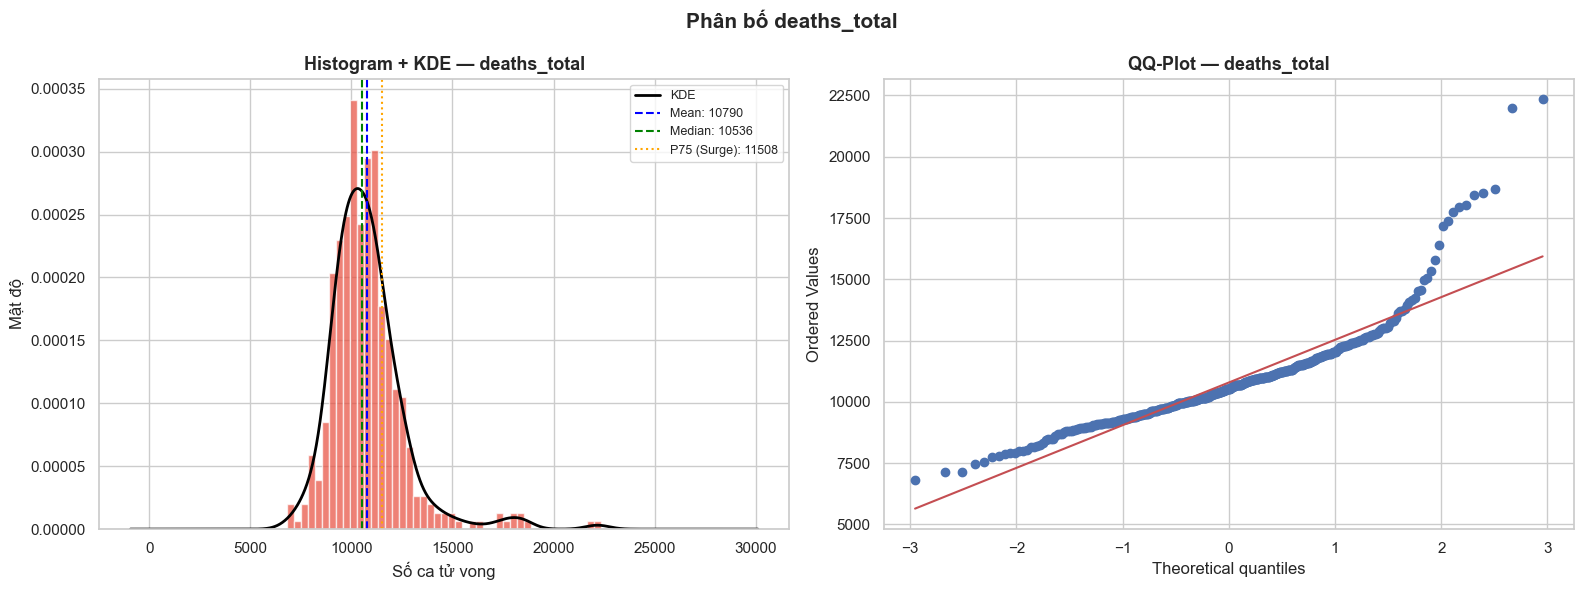

Shapiro-Wilk test: W = 0.8486, p = 3.41e-20
→ deaths_total KHÔNG tuân theo phân bố chuẩn (lệch phải do COVID outliers)


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Histogram + KDE
axes[0].hist(df['deaths_total'], bins=45, color='#e74c3c', edgecolor='white', alpha=0.7, density=True)
df['deaths_total'].plot.kde(ax=axes[0], color='black', linewidth=2, label='KDE')
axes[0].axvline(df['deaths_total'].mean(), color='blue', linestyle='--',
                label=f'Mean: {df["deaths_total"].mean():.0f}')
axes[0].axvline(df['deaths_total'].median(), color='green', linestyle='--',
                label=f'Median: {df["deaths_total"].median():.0f}')
axes[0].axvline(df['deaths_total'].quantile(0.75), color='orange', linestyle=':',
                label=f'P75 (Surge): {df["deaths_total"].quantile(0.75):.0f}')
axes[0].set_title('Histogram + KDE — deaths_total', fontweight='bold', fontsize=13)
axes[0].set_xlabel('Số ca tử vong')
axes[0].set_ylabel('Mật độ')
axes[0].legend(fontsize=9)

# QQ-plot — kiểm tra phân bố chuẩn
stats.probplot(df['deaths_total'], dist='norm', plot=axes[1])
axes[1].set_title('QQ-Plot — deaths_total', fontweight='bold', fontsize=13)

plt.suptitle('Phân bố deaths_total', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

# Shapiro-Wilk test
stat_sw, p_sw = stats.shapiro(df['deaths_total'])
print(f'Shapiro-Wilk test: W = {stat_sw:.4f}, p = {p_sw:.2e}')
if p_sw < 0.05:
    print('→ deaths_total KHÔNG tuân theo phân bố chuẩn (lệch phải do COVID outliers)')
else:
    print('→ deaths_total xấp xỉ phân bố chuẩn')

## 4.11 Phân cụm K-Means — Weather-Health Risk Groups

Phân chia các tuần thành nhóm nguy cơ dựa trên **nhiệt độ** và **tử vong**.

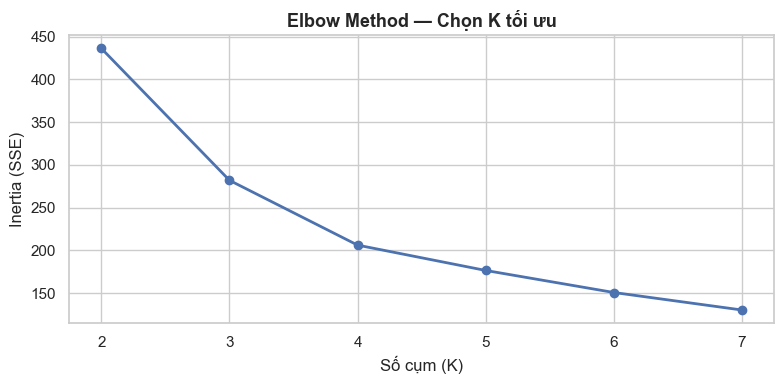

In [14]:
# Chuẩn bị dữ liệu cho K-Means
cluster_features = ['tasmax_mean_weekly_degC', 'deaths_total']
X = df[cluster_features].dropna()

# Chuẩn hóa
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Elbow method để chọn K tối ưu
inertias = []
K_range = range(2, 8)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(K_range, inertias, 'bo-', linewidth=2)
ax.set_xlabel('Số cụm (K)', fontsize=12)
ax.set_ylabel('Inertia (SSE)', fontsize=12)
ax.set_title('Elbow Method — Chọn K tối ưu', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

In [15]:
# K-Means với K=3 (3 nhóm nguy cơ)
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df['risk_cluster'] = kmeans.fit_predict(X_scaled)

# Gán nhãn theo trung bình tử vong của mỗi cụm
cluster_stats = df.groupby('risk_cluster').agg(
    avg_deaths=('deaths_total', 'mean'),
    avg_temp=('tasmax_mean_weekly_degC', 'mean'),
    count=('deaths_total', 'count'),
    surge_pct=('IsSurge', 'mean')
).round(2)

# Sắp xếp theo avg_deaths để gán nhãn
cluster_order = cluster_stats.sort_values('avg_deaths').index.tolist()
risk_labels = {cluster_order[0]: 'An toàn (Low Risk)',
               cluster_order[1]: 'Trung bình (Medium Risk)',
               cluster_order[2]: 'Nguy cơ cao (High Risk)'}

df['risk_label'] = df['risk_cluster'].map(risk_labels)

print('PHÂN CỤM WEATHER-HEALTH RISK')
print('=' * 70)
for cluster_id, label in risk_labels.items():
    row = cluster_stats.loc[cluster_id]
    print(f'{label}:')
    print(f'  Số tuần: {int(row["count"])}, TB tử vong: {row["avg_deaths"]:.0f}, '
          f'TB nhiệt độ: {row["avg_temp"]:.1f}°C, Tỷ lệ Surge: {row["surge_pct"]*100:.1f}%')
    print()

PHÂN CỤM WEATHER-HEALTH RISK
An toàn (Low Risk):
  Số tuần: 203, TB tử vong: 9725, TB nhiệt độ: 18.1°C, Tỷ lệ Surge: 2.0%

Trung bình (Medium Risk):
  Số tuần: 220, TB tử vong: 11235, TB nhiệt độ: 9.3°C, Tỷ lệ Surge: 40.0%

Nguy cơ cao (High Risk):
  Số tuần: 19, TB tử vong: 17020, TB nhiệt độ: 8.2°C, Tỷ lệ Surge: 100.0%



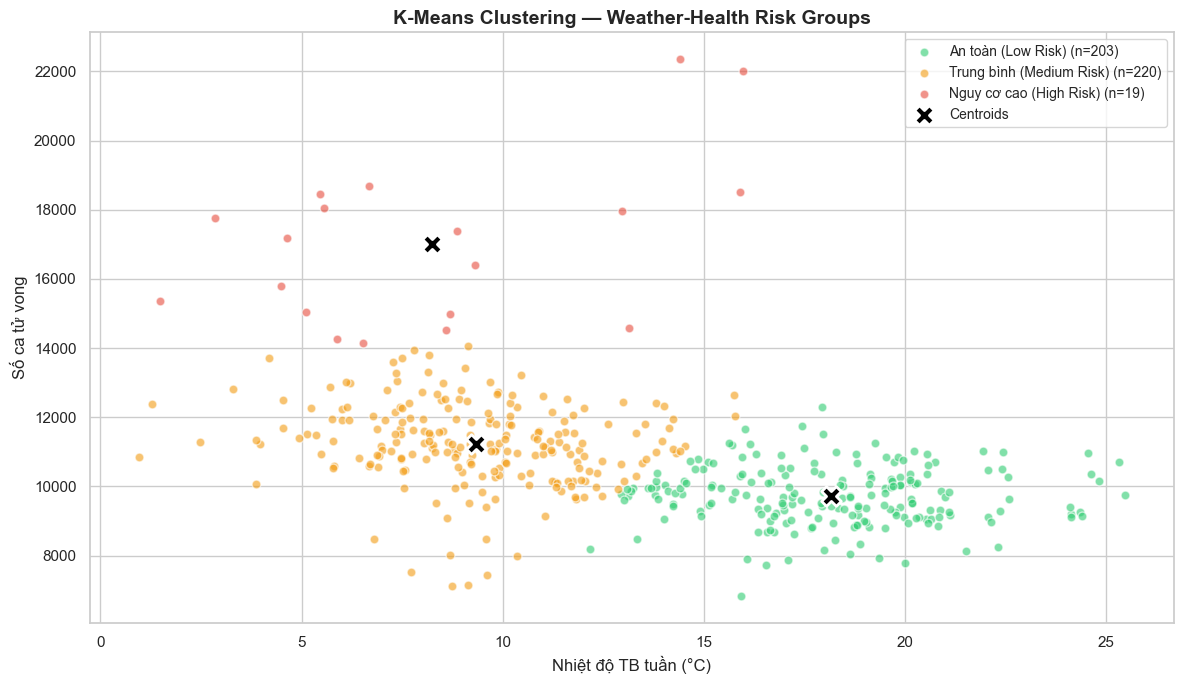

In [16]:
# Scatter plot phân cụm
fig, ax = plt.subplots(figsize=(12, 7))

colors_map = {'An toàn (Low Risk)': '#2ecc71',
              'Trung bình (Medium Risk)': '#f39c12',
              'Nguy cơ cao (High Risk)': '#e74c3c'}

for label, color in colors_map.items():
    subset = df[df['risk_label'] == label]
    ax.scatter(subset['tasmax_mean_weekly_degC'], subset['deaths_total'],
              c=color, label=f'{label} (n={len(subset)})', alpha=0.6, s=40, edgecolor='white')

# Đánh dấu centroids
centroids = scaler.inverse_transform(kmeans.cluster_centers_)
ax.scatter(centroids[:, 0], centroids[:, 1], marker='X', s=200,
           c='black', edgecolor='white', linewidth=2, label='Centroids', zorder=5)

ax.set_xlabel('Nhiệt độ TB tuần (°C)', fontsize=12)
ax.set_ylabel('Số ca tử vong', fontsize=12)
ax.set_title('K-Means Clustering — Weather-Health Risk Groups', fontweight='bold', fontsize=14)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

## 4.12 Tổng kết phân tích

In [17]:
print('=' * 70)
print('TỔNG KẾT PHÂN TÍCH — NOTEBOOK 4')
print('=' * 70)
print(f'1. Tương quan: deaths vs tasmax_mean = {r_pearson:.4f} (nghịch biến)')
print(f'2. ANOVA tháng: F = {f_stat:.2f}, p = {p_value:.2e} → mùa đông tử vong cao')
print(f'3. Biến động: Đỉnh tử vong = COVID 04/2020, đỉnh nhiệt = 07/2022')
print(f'4. Nắng nóng (>25°C): chỉ {len(hot_deaths)} tuần')
print(f'5. Quý 1 (Jan–Mar) có tử vong cao nhất do mùa đông')
print(f'6. Lag mạnh nhất: Lag {best_lag} (r = {lag_corrs[best_lag]:.4f})')
print(f'7. deaths_total: lệch phải (skew = {df["deaths_total"].skew():.3f})')
print(f'8. Rolling 3 tuần giúp loại nhiễu ngắn hạn hiệu quả')
print(f'9. Phân cụm K-Means (K=3): An toàn / Trung bình / Nguy cơ cao')
print('=' * 70)

TỔNG KẾT PHÂN TÍCH — NOTEBOOK 4
1. Tương quan: deaths vs tasmax_mean = -0.4740 (nghịch biến)
2. ANOVA tháng: F = 25.15, p = 3.94e-40 → mùa đông tử vong cao
3. Biến động: Đỉnh tử vong = COVID 04/2020, đỉnh nhiệt = 07/2022
4. Nắng nóng (>25°C): chỉ 2 tuần
5. Quý 1 (Jan–Mar) có tử vong cao nhất do mùa đông
6. Lag mạnh nhất: Lag 2 (r = -0.4917)
7. deaths_total: lệch phải (skew = 2.120)
8. Rolling 3 tuần giúp loại nhiễu ngắn hạn hiệu quả
9. Phân cụm K-Means (K=3): An toàn / Trung bình / Nguy cơ cao


---
*Trước: [3. Data Analysis with SQL](./3.%20Data%20Analysis%20with%20SQL.ipynb)* | *Tiếp: [5. Data Visualization](./5.%20Data%20Visualization.ipynb)*